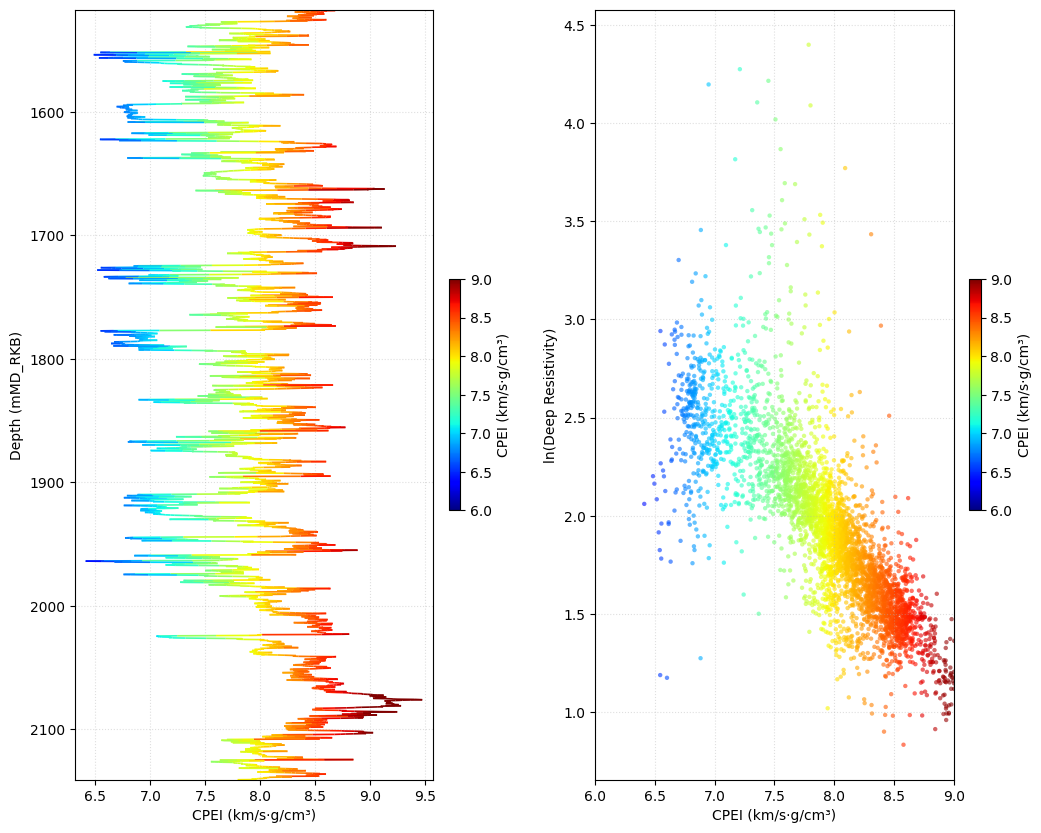

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

# Load LAS
with open('Well Log.LAS', 'r') as f:
    lines = f.readlines()

ascii_start = next(i for i, l in enumerate(lines) if l.strip().startswith('~ASCII'))
data = [[float(v) for v in line.strip().split()] for line in lines[ascii_start+1:] if line.strip()]
cols = ['DEPT','AC','ACS','BS','CALI','DEN','DENC','GR','K','NEU','PEF','RDEP','RMED','RMIC','ROP','TH','U']
df = pd.DataFrame(data, columns=cols).replace(-999.25, np.nan).set_index('DEPT')
df = df.loc[1517:2141]

# CPEI (Eq. 8 & 10, Avseth & Veggeland 2015)
# VP/VS = (304.8/AC) / (304.8/ACS) = ACS / AC
a, b, c, d, e = 0.805, -7.276, 24.581, -36.993, 21.519
df['AI']      = (304.8 / df['AC']) * df['DEN']
df['VPVS']    = df['ACS'] / df['AC']
lnAI          = np.log(df['AI'])
df['CPEI']    = 6.9 - 3.5 * (np.exp(a*lnAI**4 + b*lnAI**3 + c*lnAI**2 + d*lnAI + e) - df['VPVS'])
df['LN_RDEP'] = np.log(df['RDEP'].clip(lower=0.01))

depth = df.index.values
cpei  = df['CPEI'].values

cmap = plt.get_cmap('jet')
norm = mcolors.Normalize(vmin=6.0, vmax=9.0)
sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 10))
fig.subplots_adjust(right=0.88, wspace=0.35)

# Left: CPEI vs Depth
points   = np.array([cpei, depth]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=1.2)
lc.set_array(cpei)
ax1.add_collection(lc)
ax1.set_xlim(cpei.min() - 0.1, cpei.max() + 0.1)
ax1.set_ylim(depth.min(), depth.max())
ax1.invert_yaxis()
ax1.set_xlabel('CPEI (km/s·g/cm³)')
ax1.set_ylabel('Depth (mMD_RKB)')
ax1.grid(True, linestyle=':', alpha=0.4)
cb1 = fig.colorbar(sm, ax=ax1, fraction=0.03, pad=0.04)
cb1.set_label('CPEI (km/s·g/cm³)')

# Right: CPEI vs ln(Deep Resistivity)
ax2.scatter(df['CPEI'], df['LN_RDEP'], c=df['CPEI'], cmap=cmap, norm=norm,
            s=10, alpha=0.6, edgecolors='none')
ax2.set_xlabel('CPEI (km/s·g/cm³)')
ax2.set_ylabel('ln(Deep Resistivity)')
ax2.set_xlim(6.0, 9.0)
ax2.grid(True, linestyle=':', alpha=0.4)
cb2 = fig.colorbar(sm, ax=ax2, fraction=0.03, pad=0.04)
cb2.set_label('CPEI (km/s·g/cm³)')

plt.savefig('CPEI_plots.png', dpi=150, bbox_inches='tight')
plt.show()

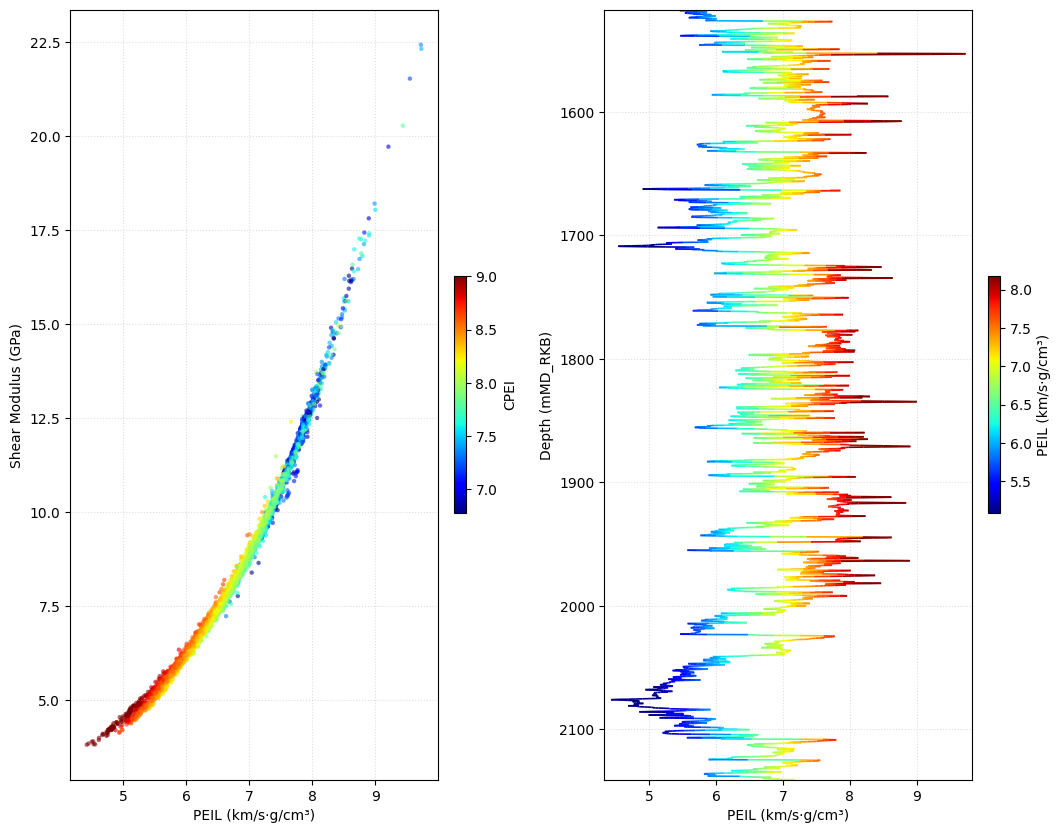

In [14]:
a, b, c, d, e = 0.805, -7.276, 24.581, -36.993, 21.519

df['VP']   = 304.8 / df['AC']
df['VS']   = 304.8 / df['ACS']
df['AI']   = df['VP'] * df['DEN']
df['VPVS'] = df['ACS'] / df['AC']
lnAI       = np.log(df['AI'])

df['CPEI'] = 6.9 - 3.5 * (np.exp(a*lnAI**4 + b*lnAI**3 + c*lnAI**2 + d*lnAI + e) - df['VPVS'])
df['PEIL'] = 6.9 + 3.5 * (0.144 * df['AI'] + 0.625 - df['VPVS'])
df['MU']   = df['DEN'] * df['VS']**2

depth = df.index.values
peil  = df['PEIL'].values

cmap = plt.get_cmap('jet')

# Normalize using CPEI for first plot
norm_cpei = mcolors.Normalize(vmin=df['CPEI'].quantile(0.02),
                              vmax=df['CPEI'].quantile(0.98))

# Normalize using PEIL for second plot
norm_peil = mcolors.Normalize(vmin=df['PEIL'].quantile(0.02),
                              vmax=df['PEIL'].quantile(0.98))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 10))
fig.subplots_adjust(wspace=0.35)

# Left: PEIL vs Shear Modulus, coloured by CPEI
ax1.scatter(df['PEIL'], df['MU'],
            c=df['CPEI'],
            cmap=cmap,
            norm=norm_cpei,
            s=10, alpha=0.6, edgecolors='none')

ax1.set_xlabel('PEIL (km/s·g/cm³)')
ax1.set_ylabel('Shear Modulus (GPa)')
ax1.grid(True, linestyle=':', alpha=0.4)

cb1 = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm_cpei),
                   ax=ax1, fraction=0.03, pad=0.04)
cb1.set_label('CPEI')

# Right: Depth vs PEIL, coloured by PEIL
points   = np.array([peil, depth]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = LineCollection(segments, cmap=cmap, norm=norm_peil, linewidth=1.2)
lc.set_array(peil)

ax2.add_collection(lc)
ax2.set_xlim(peil.min() - 0.1, peil.max() + 0.1)
ax2.set_ylim(depth.min(), depth.max())
ax2.invert_yaxis()

ax2.set_xlabel('PEIL (km/s·g/cm³)')
ax2.set_ylabel('Depth (mMD_RKB)')
ax2.grid(True, linestyle=':', alpha=0.4)

cb2 = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm_peil),
                   ax=ax2, fraction=0.03, pad=0.04)
cb2.set_label('PEIL (km/s·g/cm³)')

plt.savefig('PEIL_plots.png', dpi=150, bbox_inches='tight')
plt.show()